In [ ]:
#cài đặt thư viện
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [ ]:
#LSTM tối giản

# index 0 dành cho padding — quy ước phổ biến.
vocab = {'': 0, 'I': 1, 'like': 2, 'love': 3, 'music': 4, 'movies': 5,
         'not': 6, 'sad': 7, 'happy': 8, 'hate': 9, 'rain': 10, 'sun': 11}

train = [
    ([1, 2, 4],     1),  # "I like music"     → tích cực
    ([1, 3, 5],     1),  # "I love movies"    → tích cực
    ([1, 2, 8],     1),  # "I like happy"     → tích cực
    ([1, 9, 10],    0),  # "I hate rain"      → tiêu cực
    ([1, 6, 2, 7],  0),  # "I not like sad"   → tiêu cực
    ([1, 9, 7],     0),  # "I hate sad"       → tiêu cực
]

def to_tensors(pairs):
    seqs = [torch.tensor(s, dtype=torch.long) for s, _ in pairs]
    labels = torch.tensor([l for _, l in pairs], dtype=torch.long)
    lengths = torch.tensor([len(s) for s in seqs], dtype=torch.long)
    padded = pad_sequence(seqs, batch_first=True, padding_value=0)   # (batch, max_len)
    return padded, labels, lengths

X_train, y_train, lens_train = to_tensors(train)
print('Padded shape:', X_train.shape)
print('Sequence lengths:', lens_train.tolist())
print(X_train)

Padded shape: torch.Size([6, 4])
Sequence lengths: [3, 3, 3, 3, 4, 3]
tensor([[ 1,  2,  4,  0],
        [ 1,  3,  5,  0],
        [ 1,  2,  8,  0],
        [ 1,  9, 10,  0],
        [ 1,  6,  2,  7],
        [ 1,  9,  7,  0]])


In [ ]:
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        # padding_idx=0 → embedding của token  bị đóng băng = 0, không bị update.
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, lengths):
        embedded = self.embedding(x)                        # (B, T, E)
        # pack_padded_sequence: bỏ qua các bước padding khi LSTM tính toán → nhanh và đúng.
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)                     # h_n: (1, B, H)
        return self.fc(h_n.squeeze(0))                      # logits (B, num_classes)

model = SentimentLSTM(vocab_size=len(vocab), embed_dim=8, hidden_dim=16, num_classes=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.05)

Epoch  20  loss = 0.0000
Epoch  40  loss = 0.0000
Epoch  60  loss = 0.0000
Epoch  80  loss = 0.0000
Epoch 100  loss = 0.0000


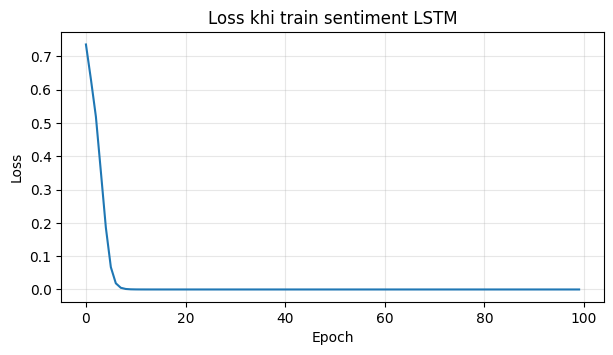

In [ ]:
X_train, y_train = X_train.to(device), y_train.to(device)
loss_history = []
for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    logits = model(X_train, lens_train)
    loss = criterion(logits, y_train)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1:3d}  loss = {loss.item():.4f}')

plt.figure(figsize=(7, 3.5))
plt.plot(loss_history); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(alpha=0.3)
plt.title('Loss khi train sentiment LSTM'); plt.show()

In [ ]:

# Test trên câu KHÔNG có trong tập train.
test_sentences = [
    'I like sun',          # mong là tích cực
    'I hate movies',       # mong là tiêu cực
    'I love music',        # mong là tích cực
    'I not love rain',     # khó — "not" + "love" + "rain"
]

def predict(sentence):
    tokens = [vocab[w] for w in sentence.split() if w in vocab]
    if not tokens:
        return None
    seq = torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(device)
    length = torch.tensor([len(tokens)])
    model.eval()
    with torch.no_grad():
        logits = model(seq, length)
        proba = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
    return proba

for s in test_sentences:
    p = predict(s)
    label = 'Tích cực' if p[1] > 0.5 else 'Tiêu cực'
    print(f'"{s:25s}"  →  {label}  (P_pos={p[1]:.2f})')

"I like sun               "  →  Tích cực  (P_pos=1.00)
"I hate movies            "  →  Tiêu cực  (P_pos=0.00)
"I love music             "  →  Tích cực  (P_pos=1.00)
"I not love rain          "  →  Tiêu cực  (P_pos=0.00)


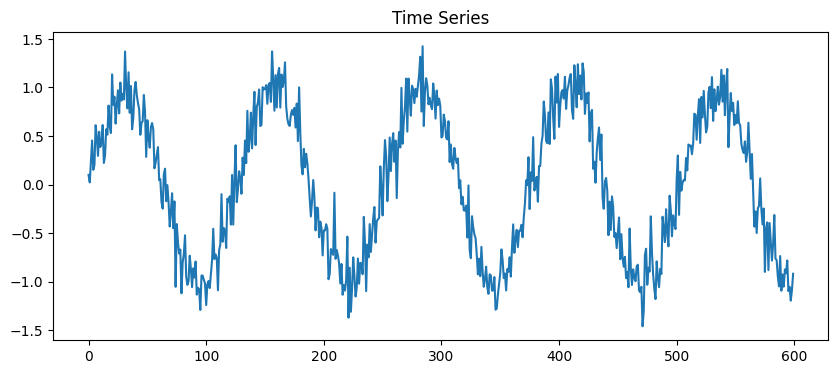

(580, 20, 1)
(580, 1)
(406, 20, 1)
(87, 20, 1)
(87, 20, 1)
Epoch 10/100 | Train Loss=0.005668 | Val Loss=0.006896
Epoch 10/100 | Train Loss=0.005668 | Val Loss=0.006896
Epoch 20/100 | Train Loss=0.005655 | Val Loss=0.006902
Epoch 20/100 | Train Loss=0.005655 | Val Loss=0.006902
Epoch 30/100 | Train Loss=0.005645 | Val Loss=0.006910
Epoch 30/100 | Train Loss=0.005645 | Val Loss=0.006910
Epoch 40/100 | Train Loss=0.005637 | Val Loss=0.006917
Epoch 40/100 | Train Loss=0.005637 | Val Loss=0.006917
Epoch 50/100 | Train Loss=0.005631 | Val Loss=0.006924
Epoch 50/100 | Train Loss=0.005631 | Val Loss=0.006924
Epoch 60/100 | Train Loss=0.005624 | Val Loss=0.006931
Epoch 60/100 | Train Loss=0.005624 | Val Loss=0.006931
Epoch 70/100 | Train Loss=0.005618 | Val Loss=0.006938
Epoch 70/100 | Train Loss=0.005618 | Val Loss=0.006938
Epoch 80/100 | Train Loss=0.005612 | Val Loss=0.006944
Epoch 80/100 | Train Loss=0.005612 | Val Loss=0.006944
Epoch 90/100 | Train Loss=0.005607 | Val Loss=0.006950
Epoch 

In [ ]:
#dự đoán chuỗi thời gian bằng LSTM
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# tạo dữ liệu chuỗi thời gian
np.random.seed(42)

# 600 điểm dữ liệu
N = 600

t = np.arange(N)

# Sin + noise
data = np.sin(0.05 * t) + 0.2 * np.random.randn(N)

plt.figure(figsize=(10,4))
plt.plot(data)
plt.title("Time Series")
plt.show()

# chuan hoa min- max
scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(
    data.reshape(-1,1)
)
# tạo Sliding window
def create_sequences(data, seq_length):

    X = []
    y = []

    for i in range(len(data)-seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])

    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, seq_length)

print(X.shape)
print(y.shape)

#chia val/train/test
total = len(X)

train_size = int(total * 0.70)
val_size = int(total * 0.15)

test_size = total - train_size - val_size

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

# chuyển sang tensor
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)

X_val = torch.FloatTensor(X_val)
y_val = torch.FloatTensor(y_val)

X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)



# data loader
batch_size = 32

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=batch_size,
    shuffle=False
)

val_loader = DataLoader(
    TensorDataset(X_val, y_val),
    batch_size=batch_size,
    shuffle=False
)

#xây dựng LSTM
class LSTMModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=32,
            batch_first=True
        )

        self.fc = nn.Linear(32, 1)

    def forward(self, x):

        output, (h_n, c_n) = self.lstm(x)

        out = self.fc(output[:, -1, :])

        return out

# khởi tạo model
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model_lstm = LSTMModel().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model_lstm.parameters(),
    lr=1e-3
)

#train 100 epoch
epochs = 100

train_losses = []
val_losses = []

for epoch in range(epochs):

    model_lstm.train()

    running_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        pred = model_lstm(X_batch)

        loss = criterion(pred, y_batch)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    # validation
    model_lstm.eval()

    val_loss = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            pred = model_lstm(X_batch)

            loss = criterion(pred, y_batch)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)


    epochs = 100

train_losses = []
val_losses = []

for epoch in range(epochs):

    model_lstm.train()

    running_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        pred = model_lstm(X_batch)

        loss = criterion(pred, y_batch)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    # validation
    model_lstm.eval()

    val_loss = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            pred = model_lstm(X_batch)

            loss = criterion(pred, y_batch)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if (epoch+1) % 10 == 0:
        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss={train_loss:.6f} | "
            f"Val Loss={val_loss:.6f}"
        )

    if (epoch+1) % 10 == 0:
        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss={train_loss:.6f} | "
            f"Val Loss={val_loss:.6f}"
        )



In [ ]:
seq_length = 20

In [ ]:
#test
model_lstm.eval()

with torch.no_grad():

    predictions = model_lstm(
        X_test.to(device)
    ).cpu().numpy()

actual = y_test.numpy()

mse_lstm = mean_squared_error(
    actual,
    predictions
)

print("LSTM Test MSE =", mse_lstm)

LSTM Test MSE = 0.005168775096535683


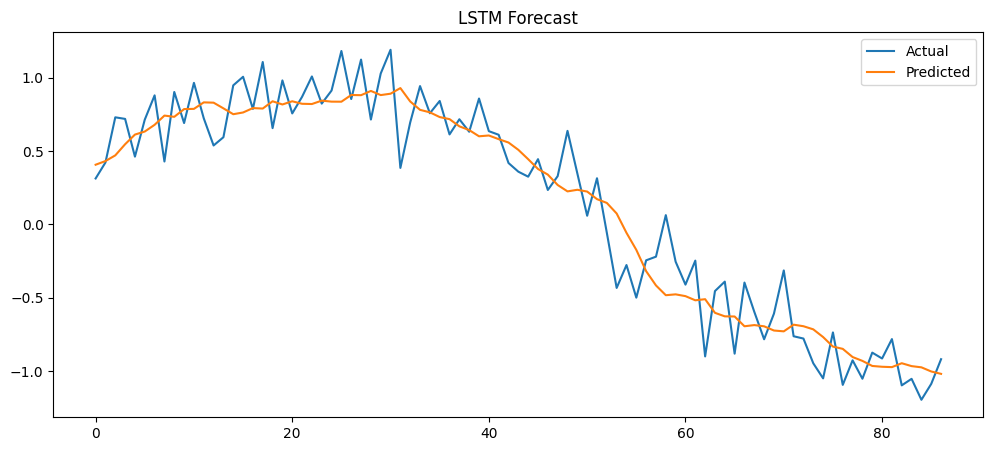

In [ ]:
#chuyển về gia tri gốc
pred_original = scaler.inverse_transform(
    predictions
)

actual_original = scaler.inverse_transform(
    actual
)

# vẽ predict va actual
plt.figure(figsize=(12,5))

plt.plot(
    actual_original,
    label="Actual"
)

plt.plot(
    pred_original,
    label="Predicted"
)

plt.legend()
plt.title("LSTM Forecast")
plt.show()

# vẽ RNN so sánh
class RNNModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.rnn = nn.RNN(
            input_size=1,
            hidden_size=32,
            batch_first=True
        )

        self.fc = nn.Linear(32,1)

    def forward(self, x):

        output, h_n = self.rnn(x)

        out = self.fc(output[:, -1, :])

        return out

In [ ]:
#train RNN
model_rnn = RNNModel().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model_rnn.parameters(),
    lr=1e-3
)

for epoch in range(100):

    model_rnn.train()

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        pred = model_rnn(X_batch)

        loss = criterion(pred, y_batch)

        loss.backward()

        optimizer.step()
#test RNN
model_rnn.eval()

with torch.no_grad():

    pred_rnn = model_rnn(
        X_test.to(device)
    ).cpu().numpy()

mse_rnn = mean_squared_error(
    actual,
    pred_rnn
)

print("RNN Test MSE =", mse_rnn)
print("LSTM Test MSE =", mse_lstm)

RNN Test MSE = 0.005147804971784353
LSTM Test MSE = 0.005168775096535683


In [ ]:
#BAI 2
#cài thư viện
!pip install datasets

In [ ]:
# cài đat thu viện
import re
import numpy as np
from collections import Counter

import torch
import torch.nn as nn

from datasets import load_dataset

from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from torch.nn.utils.rnn import pad_sequence
from torch.nn.utils.rnn import pack_padded_sequence

#load IMDB
dataset = load_dataset("imdb")

train_texts = dataset["train"]["text"][:5000]
train_labels = dataset["train"]["label"][:5000]

test_texts = dataset["test"]["text"][:1000]
test_labels = dataset["test"]["label"][:1000]

print(len(train_texts))
print(len(test_texts))

#tokenize
def tokenize(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z ]', '', text)

    return text.split()
#build vocabulary
counter = Counter()

for text in train_texts:

    tokens = tokenize(text)

    counter.update(tokens)

vocab = {
    "<PAD>":0,
    "<UNK>":1
}

for word, freq in counter.items():

    if freq >= 2:

        vocab[word] = len(vocab)

print("Vocab size =", len(vocab))

#encode text
def encode(text):

    tokens = tokenize(text)

    return [
        vocab.get(token, 1)
        for token in tokens
    ]

#dataset class
class IMDBDataset(Dataset):

    def __init__(self,texts,labels):

        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self,idx):

        return (
            torch.tensor(
                encode(self.texts[idx]),
                dtype=torch.long
            ),
            torch.tensor(
                self.labels[idx],
                dtype=torch.float
            )
        )

# padding and length
def collate_fn(batch):

    texts = [x[0] for x in batch]

    labels = torch.tensor(
        [x[1] for x in batch]
    )

    lengths = torch.tensor(
        [len(x) for x in texts]
    )

    padded = pad_sequence(
        texts,
        batch_first=True,
        padding_value=0
    )

    return padded, lengths, labels


# data loader
train_dataset = IMDBDataset(
    train_texts,
    train_labels
)

test_dataset = IMDBDataset(
    test_texts,
    test_labels
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn
)

5000
1000
Vocab size = 23556


In [ ]:
!pip install -U datasets huggingface_hub

In [ ]:
import datasets
import huggingface_hub

print(datasets.__version__)
print(huggingface_hub.__version__)




2.19.1
0.23.5


In [ ]:
#cài đặt hug
!pip install datasets==2.19.1
!pip install huggingface_hub==0.23.5

  Using cached huggingface_hub-1.19.0-py3-none-any.whl.metadata (14 kB)
Using cached huggingface_hub-1.19.0-py3-none-any.whl (693 kB)
  Using cached huggingface_hub-0.23.5-py3-none-any.whl.metadata (12 kB)
Using cached huggingface_hub-0.23.5-py3-none-any.whl (402 kB)
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.19.0
    Uninstalling huggingface_hub-1.19.0:
      Successfully uninstalled huggingface_hub-1.19.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires huggingface-hub<2.0,>=0.33.5, but you have huggingface-hub 0.23.5 which is incompatible.
peft 0.19.1 requires huggingface_hub>=0.25.0, but you have huggingface-hub 0.23.5 which is incompatible.
diffusers 0.38.0 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.23.5 which is incompatible.
transformers 5.10.2 requires huggi

In [ ]:
from datasets import load_dataset

dataset = load_dataset("imdb")

print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [ ]:
#BiLSTM
class BiLSTM(nn.Module):

    def __init__(self,vocab_size):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            100,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            input_size=100,
            hidden_size=64,
            num_layers=2,
            dropout=0.3,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(
            64*2,
            1
        )

    def forward(self,x,lengths):

        embedded = self.embedding(x)

        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        output,(h_n,c_n) = self.lstm(packed)

        hidden = torch.cat(
            (
                h_n[-2],
                h_n[-1]
            ),
            dim=1
        )

        out = self.fc(hidden)

        return out.squeeze()

In [ ]:
#initState
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = BiLSTM(
    len(vocab)
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)


#train
epochs = 10

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for texts,lengths,labels in train_loader:

        texts = texts.to(device)

        lengths = lengths.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(
            texts,
            lengths
        )

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch {epoch+1}, "
        f"Loss={total_loss/len(train_loader):.4f}"
    )


# đanh gia acc + f1
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for texts,lengths,labels in test_loader:

        texts = texts.to(device)

        lengths = lengths.to(device)

        outputs = model(
            texts,
            lengths
        )

        preds = (
            torch.sigmoid(outputs)
            > 0.5
        ).int()

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

#acc & f1
acc = accuracy_score(
    all_labels,
    all_preds
)

f1 = f1_score(
    all_labels,
    all_preds
)

print("Accuracy =", acc)
print("F1 Score =", f1)

Epoch 1, Loss=0.0556
Epoch 2, Loss=0.0002
Epoch 3, Loss=0.0001
Epoch 4, Loss=0.0001
Epoch 5, Loss=0.0001
Epoch 6, Loss=0.0000
Epoch 7, Loss=0.0000
Epoch 8, Loss=0.0000
Epoch 9, Loss=0.0000
Epoch 10, Loss=0.0000
Accuracy = 1.0
F1 Score = 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#BÀI 3:
#import thư viện
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

In [ ]:
#tạo dữ lieu
text = """
Deep learning is a subset of machine learning.
Neural networks can learn complex patterns from data.
LSTM networks are useful for sequence prediction tasks.
Recurrent neural networks process sequential information.
Artificial intelligence is changing the world.
"""

# Nhân lên để có dữ liệu đủ lớn
text = text * 500

print("Total characters:", len(text))

Total characters: 131500


In [ ]:
#tạo vocabulary
chars = sorted(list(set(text)))

vocab_size = len(chars)

print("Vocabulary size:", vocab_size)

char2idx = {
    ch: idx
    for idx, ch in enumerate(chars)
}

idx2char = {
    idx: ch
    for idx, ch in enumerate(chars)
}


#encode văn bản
encoded_text = [
    char2idx[ch]
    for ch in text
]

Vocabulary size: 33


In [ ]:
#tạo dataset
seq_length = 50

X = []
y = []

for i in range(len(encoded_text) - seq_length):

    X.append(
        encoded_text[i:i+seq_length]
    )

    y.append(
        encoded_text[i+seq_length]
    )

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)


#tensor dataset
X = torch.LongTensor(X)
y = torch.LongTensor(y)

dataset = TensorDataset(X, y)

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

(131450, 50)
(131450,)


In [ ]:
#LSTM
class CharLSTM(nn.Module):

    def __init__(self, vocab_size):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            64
        )

        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=128,
            num_layers=2,
            batch_first=True
        )

        self.fc = nn.Linear(
            128,
            vocab_size
        )

    def forward(self, x):

        x = self.embedding(x)

        output, (h_n, c_n) = self.lstm(x)

        out = self.fc(
            output[:, -1, :]
        )

        return out

#khởi tao model
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = CharLSTM(
    vocab_size
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)


#train model
epochs = 50

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for X_batch, y_batch in loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(
            outputs,
            y_batch
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{epochs} "
        f"Loss = {total_loss/len(loader):.4f}"
    )




Epoch 1/50 Loss = 0.2446
Epoch 2/50 Loss = 0.0011
Epoch 3/50 Loss = 0.0002
Epoch 4/50 Loss = 0.0001
Epoch 5/50 Loss = 0.0061
Epoch 6/50 Loss = 0.0001
Epoch 7/50 Loss = 0.0000
Epoch 8/50 Loss = 0.0000
Epoch 9/50 Loss = 0.0000
Epoch 10/50 Loss = 0.0000
Epoch 11/50 Loss = 0.0000
Epoch 12/50 Loss = 0.0000
Epoch 13/50 Loss = 0.0000
Epoch 14/50 Loss = 0.0000
Epoch 15/50 Loss = 0.0000
Epoch 16/50 Loss = 0.0000
Epoch 17/50 Loss = 0.0035
Epoch 18/50 Loss = 0.0000
Epoch 19/50 Loss = 0.0000
Epoch 20/50 Loss = 0.0000
Epoch 21/50 Loss = 0.0000
Epoch 22/50 Loss = 0.0000
Epoch 23/50 Loss = 0.0000
Epoch 24/50 Loss = 0.0000
Epoch 25/50 Loss = 0.0000
Epoch 26/50 Loss = 0.0000
Epoch 27/50 Loss = 0.0000
Epoch 28/50 Loss = 0.0000
Epoch 29/50 Loss = 0.0000
Epoch 30/50 Loss = 0.0000
Epoch 31/50 Loss = 0.0000
Epoch 32/50 Loss = 0.0000
Epoch 33/50 Loss = 0.0000
Epoch 34/50 Loss = 0.0000
Epoch 35/50 Loss = 0.0000
Epoch 36/50 Loss = 0.0000
Epoch 37/50 Loss = 0.0000
Epoch 38/50 Loss = 0.0000
Epoch 39/50 Loss = 0.

In [ ]:
#hàm sinh văn bản Greedy

def generate_greedy(
    model,
    seed,
    length=300
):

    model.eval()

    generated = seed

    for _ in range(length):

        seq = [
            char2idx[ch]
            for ch in generated[-seq_length:]
        ]

        x = torch.LongTensor(
            [seq]
        ).to(device)

        with torch.no_grad():

            logits = model(x)

        next_idx = torch.argmax(
            logits,
            dim=1
        ).item()

        generated += idx2char[next_idx]

    return generated

In [ ]:
#sinh văn bản Greedy
seed = "Deep learning "

result = generate_greedy(
    model,
    seed,
    length=500
)

print(result)

Deep learning is a subset of machine learning.
Neural networks can learn complex patterns from data.
LSTM networks are useful for sequence prediction tasks.
Recurrent neural networks process sequential information.
Artificial intelligence is changing the world.

Deep learning is a subset of machine learning.
Neural networks can learn complex patterns from data.
LSTM networks are useful for sequence prediction tasks.
Recurrent neural networks process sequential information.
Artificial intelligence is changing 


In [ ]:
#hàm temperature
def generate_temperature(
    model,
    seed,
    length=300,
    temperature=0.8
):

    model.eval()

    generated = seed

    for _ in range(length):

        seq = [
            char2idx[ch]
            for ch in generated[-seq_length:]
        ]

        x = torch.LongTensor(
            [seq]
        ).to(device)

        with torch.no_grad():

            logits = model(x)

        logits = logits / temperature

        probs = F.softmax(
            logits,
            dim=1
        ).cpu().numpy()[0]

        next_idx = np.random.choice(
            vocab_size,
            p=probs
        )

        generated += idx2char[next_idx]

    return generated


#sinh văn bản Temperature
seed = "Deep learning "

print(
    generate_temperature(
        model,
        seed,
        length=500,
        temperature=0.5
    )
)

Deep learning is a subset of machine learning.
Neural networks can learn complex patterns from data.
LSTM networks are useful for sequence prediction tasks.
Recurrent neural networks process sequential information.
Artificial intelligence is changing the world.

Deep learning is a subset of machine learning.
Neural networks can learn complex patterns from data.
LSTM networks are useful for sequence prediction tasks.
Recurrent neural networks process sequential information.
Artificial intelligence is changing 
